In [ ]:
%matplotlib inline
from wrapper import BasicEnvironmentRGB, DomainRandomization, RandomColorReplace
import gymnasium as gym
from gymnasium.wrappers import FrameStackObservation, TransformObservation, ResizeObservation
from matplotlib import pyplot as plt
from rltesting.torch_rl.utils import random_sample_single_env
from rltesting.torch_rl.buffers import ReplayBuffer
from rltesting.torch_rl.models import MLP
from fvd_models import Encoder, Decoder, AEVAE
import numpy as np
import torch
import skdim

np.random.seed(42)
torch.manual_seed(0)
# gym.utils.seeding.np_random(0)

to_numpy = lambda x: x.cpu().detach().numpy()
framestack = 2
latent_dim = 512
obs_shape = 64
data_steps = 40000
num_epochs = 50
steps_per_epoch = 200
env = gym.make('Acrobot-v1', render_mode="rgb_array")
env = BasicEnvironmentRGB(env)
# env = RandomColorReplace(env)
# env = gym.make('Pendulum-v1', render_mode='rgb_array')
env = DomainRandomization(env, {"LINK_LENGTH_1": lambda: np.random.choice([0.5, 1.0, 1.5, 2.0]), "LINK_LENGTH_2": lambda: np.random.choice([0.5, 1.0, 1.5, 2.0])})
# env = DomainRandomization(env, {"g": (5.0, 20.0)})
env = ResizeObservation(env, (obs_shape, obs_shape))
env = FrameStackObservation(env, stack_size=framestack)
env = TransformObservation(env, lambda obs: np.transpose(obs, (1, 2, 0, 3)), observation_space=gym.spaces.Box(0, 255, (framestack, 3, obs_shape, obs_shape), dtype=np.uint8))
env = TransformObservation(env, lambda obs: np.reshape(obs, (obs_shape, obs_shape, 3 * framestack)), observation_space=gym.spaces.Box(0, 255, (obs_shape, obs_shape, 3 * framestack), dtype=np.uint8))
buffer_shapes = [(obs_shape, obs_shape, 3 * framestack), (), (), ()]
dtypes = [np.uint8, np.float32, np.float32, np.float32]
buffer = ReplayBuffer(buffer_shapes, dtypes, buffer_size=data_steps)

In [2]:
obs, _ = env.reset()

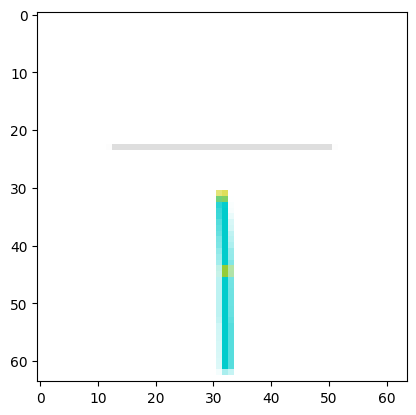

In [3]:
plt.imshow(obs[:, :, :3] / 255)

In [4]:
samples = random_sample_single_env(env, num_steps=data_steps)
for i in range(data_steps):
    buffer.add_sample([samples[j][i] for j in range(len(samples))].copy())

In [5]:
encoder = Encoder(framestack, latent_dim, obs_shape).cuda()
decoder = Decoder(encoder.conv_dim, framestack, latent_dim).cuda()
opt = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), 3e-4)
scheduler = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.97)

In [6]:
losses = []
for i in range(1, num_epochs + 1):
    for _ in range(steps_per_epoch):
        samples = buffer.sample(256)
        obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
        latent = encoder(obs)
        reconstruction = decoder(latent)
        loss = torch.nn.functional.mse_loss(reconstruction, obs)
        loss.backward()
        opt.step()
        opt.zero_grad()
        losses.append(loss.detach().cpu().numpy())
    scheduler.step()
    if i % 10 == 0:
        print(i * steps_per_epoch)

4000
8000
12000
16000
20000


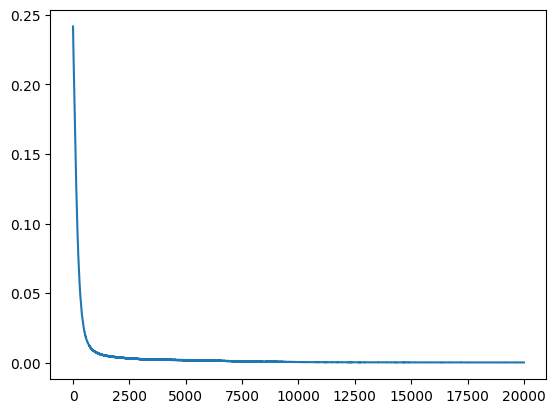

In [7]:
plt.plot(losses)

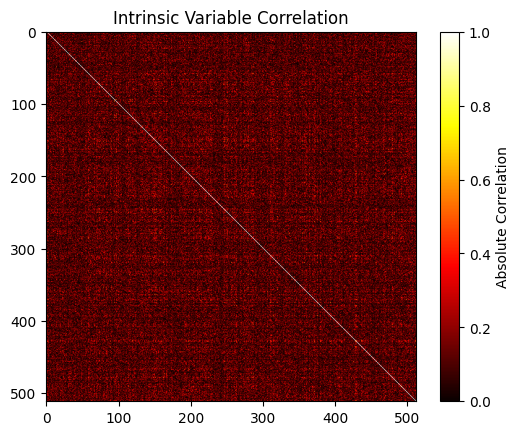

In [8]:
num_samples = 2048
with torch.no_grad():
    samples_ = buffer.sample(num_samples)
    obs = (torch.tensor(samples_[0]).float().transpose(-3, -1) / 255).cuda()
    latent = encoder(obs).cpu().numpy()

corr = np.corrcoef(latent, rowvar=False)
plt.imshow(np.abs(corr), cmap="hot", vmin=0, vmax=1)
plt.colorbar(label="Absolute Correlation")
plt.title("Intrinsic Variable Correlation")
plt.show()

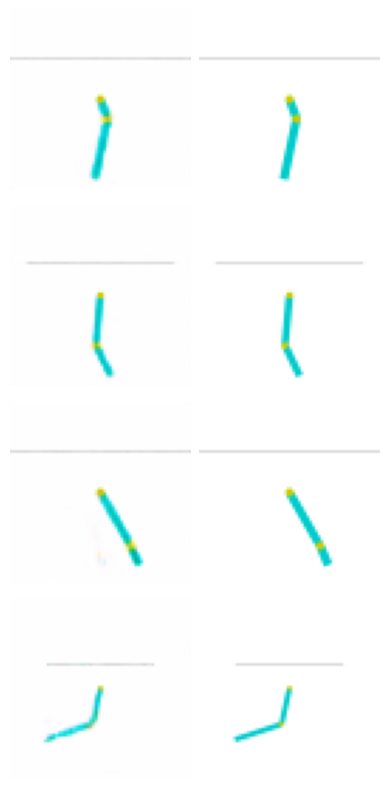

In [9]:
num_img = 4
fig, axs = plt.subplots(nrows=num_img, ncols=2, figsize=(4, 2 * num_img))
for i in range(4):
    axs[i][0].imshow(reconstruction[i].detach().cpu().transpose(-3, -1).numpy()[:, :, :3])
    axs[i][0].axis("off")
    axs[i][1].imshow(samples[0][i][:, :, :3])
    axs[i][1].axis("off")
plt.tight_layout()
plt.show()
fig.savefig("direct_dim.png")

In [10]:
latent_ID = []
image_ID = []

for _ in range(20):
    samples = buffer.sample(2048)
    obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
    latent = encoder(obs)
    unique_latents = np.unique(latent.detach().cpu().numpy(), axis=0)
    unique_obs = np.unique(obs.detach().cpu().numpy(), axis=0).reshape(-1, 3 * framestack*obs_shape*obs_shape)

    latent_ID.append(skdim.id.MLE().fit(unique_latents).dimension_)
    image_ID.append(skdim.id.MLE().fit(unique_obs).dimension_)

print(f"Latent ID: {np.mean(latent_ID)} +- {np.std(latent_ID)}")
print(f"Image ID: {np.mean(image_ID)} +- {np.std(image_ID)}")


Latent ID: 6.392667696449736 +- 0.07659350348186841
Image ID: 9.35513366029679 +- 0.14283359169328108


8000
16000
24000
32000
40000


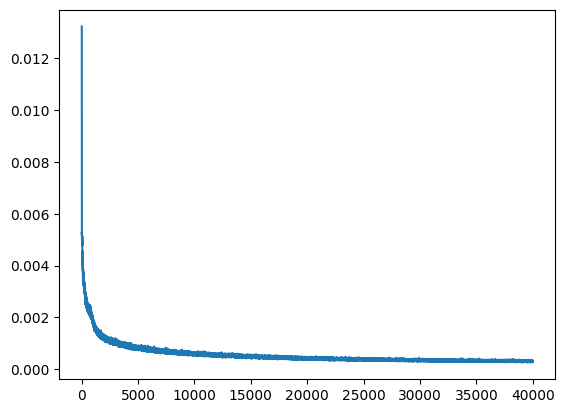

In [11]:
plt.close('all')
%matplotlib inline
intrinsic_dim = round(np.mean(latent_ID))
double_autoencoder = AEVAE(encoder, decoder, latent_dim, intrinsic_dim, penalty_coef=1e-4).cuda()
int_opt = torch.optim.AdamW(double_autoencoder.parameters(), 3e-4)
int_scheduler = torch.optim.lr_scheduler.ExponentialLR(int_opt, gamma=0.97)
losses = []
for i in range(1, num_epochs + 1):
    for _ in range(2 * steps_per_epoch):
        samples = buffer.sample(256)
        obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
        loss = double_autoencoder.reconstruction_loss(obs)
        loss.backward()
        int_opt.step()
        int_opt.zero_grad()
        losses.append(loss.detach().cpu().numpy())
    int_scheduler.step()
    if i % 10 == 0:
        print(i * 2 * steps_per_epoch)
plt.plot(losses)

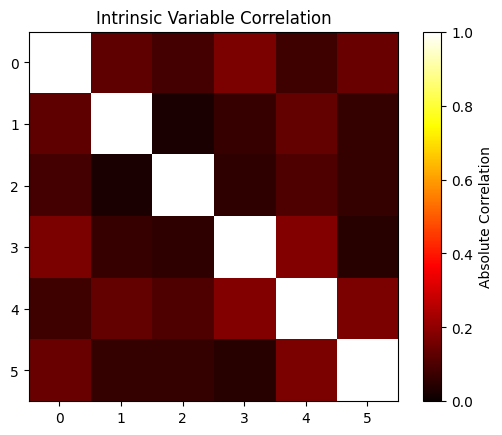

In [18]:
plt.close('all')
%matplotlib inline
num_samples = 2048
with torch.no_grad():
    samples = buffer.sample(num_samples)
    obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
    intrinsic = double_autoencoder.double_encode(obs).cpu().numpy()

corr = np.corrcoef(intrinsic, rowvar=False)
plt.imshow(np.abs(corr), cmap="hot", vmin=0, vmax=1)
plt.colorbar(label="Absolute Correlation")
plt.title("Intrinsic Variable Correlation")
plt.show()

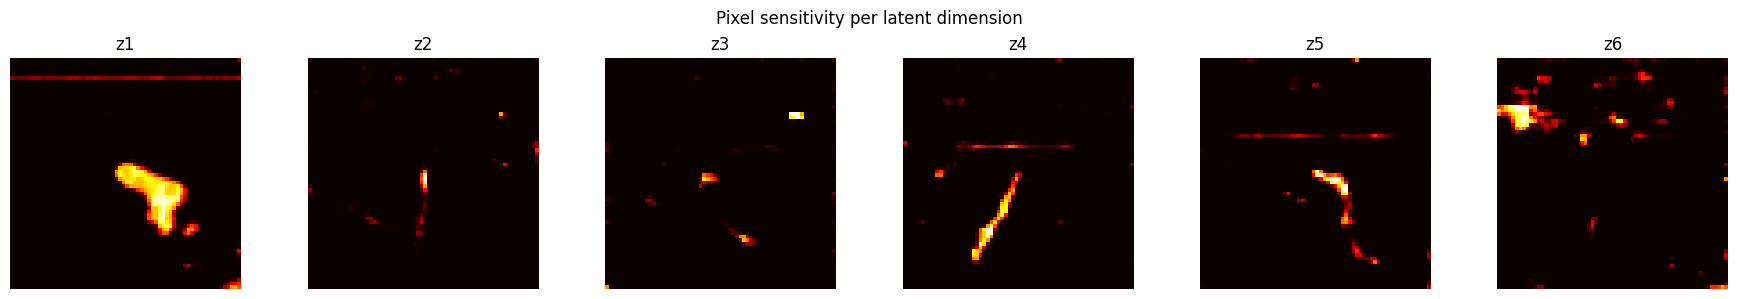

In [19]:
def plot_jacobians(double_autoencoder, obs, intrinsic_dim, eps=0.5):
    double_autoencoder.eval()
    with torch.no_grad():
        intrinsic = double_autoencoder.double_encode(obs)
        
        fig, axs = plt.subplots(1, intrinsic_dim, figsize=(3 * intrinsic_dim, 3))
        for i in range(intrinsic_dim):
            plus = intrinsic[0:1].clone()
            minus = intrinsic[0:1].clone()
            plus[0, i] += eps
            minus[0, i] -= eps
            diff = double_autoencoder.double_decode(plus) - double_autoencoder.double_decode(minus)
            sensitivity = diff[0, :3].abs().mean(0).cpu().numpy()
            
            axs[i].imshow(sensitivity.T, cmap="hot")
            axs[i].set_title(f"z{i+1}")
            axs[i].axis("off")
    
    plt.suptitle("Pixel sensitivity per latent dimension")
    plt.tight_layout()
    plt.show()
plot_jacobians(double_autoencoder, obs, intrinsic_dim)

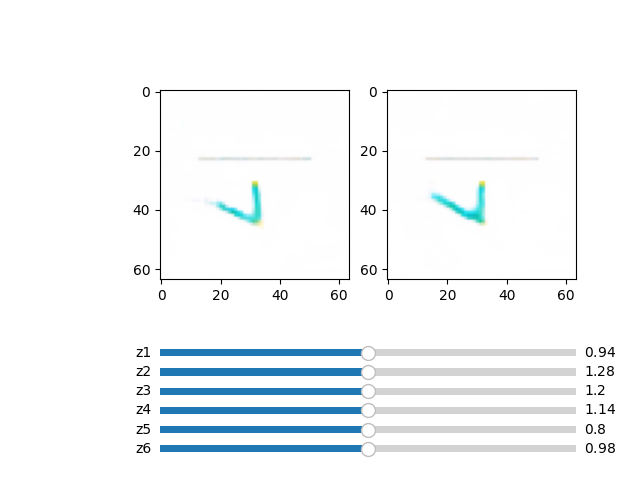

In [14]:
plt.close("all")
from matplotlib.widgets import Slider
%matplotlib widget

double_autoencoder.eval()

def decode(intrinsic):
    with torch.no_grad():
        intrinsic_tensor = torch.tensor(intrinsic).cuda()
        reconstruction = double_autoencoder.double_decode(intrinsic_tensor)
        reconstruction = to_numpy(reconstruction[0].transpose(-3, -1))
    return reconstruction[:, :, :3], reconstruction[:, :, 3:]

with torch.no_grad():
    intrinsic = double_autoencoder.double_encode(obs)
intrinsic = to_numpy(intrinsic[0])

img = decode(intrinsic)
f, axs = plt.subplots(1, 2)
img_handle1 = axs[0].imshow(img[0])
img_handle2 = axs[1].imshow(img[1])

plt.subplots_adjust(left=0.25, bottom=0.35)

slider_axes = []
sliders = []
for i in range(intrinsic_dim):
    ax = plt.axes([0.25, 0.25 - i*0.04, 0.65, 0.03])
    slider_axes.append(ax)
    slider = Slider(ax, f'z{i+1}', intrinsic[i]-20.0, intrinsic[i]+20.0, valinit=intrinsic[i])
    sliders.append(slider)

def update(val):
    for i, slider in enumerate(sliders):
        intrinsic[i] = slider.val
    img = decode(intrinsic)
    img_handle1.set_data(img[0])
    img_handle2.set_data(img[1])
    plt.draw()

for slider in sliders:
    slider.on_changed(update)

plt.show()

[111.14422     5.546322    5.295184    4.492978    4.0498457   3.5056167]
[[-0.40947536 -0.40853402 -0.40900776 -0.40636247 -0.4058087  -0.4102821 ]
 [ 0.17928484  0.3184075   0.13889119 -0.4830989  -0.6293811   0.46655944]
 [ 0.49676576 -0.74596655  0.18142301 -0.30729422  0.18155709  0.19092062]
 [-0.28371933 -0.30710185  0.6881881   0.39813372 -0.43514934 -0.06102105]
 [ 0.1016449   0.28093806  0.51458853 -0.47919846  0.19700214 -0.6144101 ]
 [-0.68013406 -0.0448643   0.20519114 -0.34483856  0.42198455  0.4430766 ]]


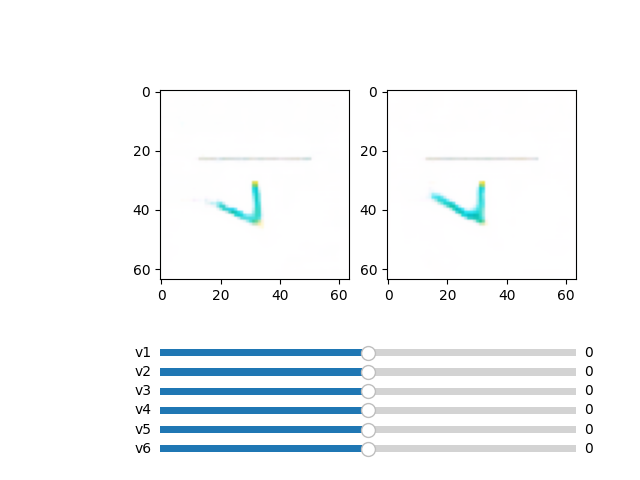

In [15]:
plt.close("all")

intrinsic = double_autoencoder.double_encode(obs)
intrinsic_base = to_numpy(intrinsic[0])
u, s, v = np.linalg.svd(to_numpy(intrinsic), full_matrices=False)
print(s)
print(v)
f, axs = plt.subplots(1, 2)

img = decode(intrinsic_base)
img_handle1 = axs[0].imshow(img[0])
img_handle2 = axs[1].imshow(img[1])

plt.subplots_adjust(left=0.25, bottom=0.35)

slider_axes = []
sliders = []
for i in range(intrinsic_dim):
    ax = plt.axes([0.25, 0.25 - i*0.04, 0.65, 0.03])
    slider_axes.append(ax)
    slider = Slider(ax, f'v{i+1}', -10.0, +10.0, valinit=0.0)
    sliders.append(slider)

def update(val):
    intrinsic_temp = intrinsic_base.copy()
    for i, slider in enumerate(sliders):
        intrinsic_temp += slider.val * v[i]
    img = decode(intrinsic_temp)
    img_handle1.set_data(img[0])
    img_handle2.set_data(img[1])
    
    f.canvas.draw_idle()

for slider in sliders:
    slider.on_changed(update)

plt.show()

In [16]:
# 